# Week-6: Amplitude Modulation
In this lab we will see **AM** (de)modulation. For this purpose we will use **IQ** record files. First recording is done with application called "rtl_sdr". rtl_sdr app has a number of input parameters which allow you to set the **center frequency, sampling rate, number of samples** to take, etc. First record contains **airband** data. Second record is from **HF** frequency band. 

## IQ Data Formats
Traditionally IQ data is stored into a file in **binary** format. Samples are recoreded and just written into file one-by-one. This is called **interleaved** data. It looks like I-Q-I-Q-... and so on. There is also **split-format** where a number of I samples followed by number of Q samples. Split data is like II----IQQ----QII----IQQ----Q... and so on. 

In binary format you may have **metadata** in addition to IQ data mentioned earlier. Typically metadata contain information about sample rate, center frequency, version, date and time to name a few. 

Another way to store IQ data is to treat it as **stereo sound** data. This is a little bit hack! Because wav files are supported uniformly by many tools nearly in every environment. 

More modern way way today is to use **SigMF** standard. It is a recent standard format based on HDF5 you can look into. 

You should be careful when reading IQ data from a record. You must know data format of the file you are looking. Last thing to consider is individual sample (I or Q) data type. This can be anything signed/unsigned integer (6-bit, 16-bit or 32-bit) or a floating data type. If it consists of more than one byte, **endianness** is also important. 

All of the above comments in mind, we will be first using 8-bit unsigned integer interleaved file format, in this lab. 

## RF Data costs lots of memory!
IQ data as you should know consists of complex data. You need some space in order to save it. And the space increases as the bandwidth increases. So you need more space for wideband signals. Even at low bandwidths you will see that how much space you need. 



### Walkthrough Example

Consider example record given in your repo, `rtl_am.dat`. This file has been recorded using RTL-SDR set to **135.5MHz** at a rate of **2.048Msps**, ie 2048000 samples per second. RTL-SDR produces unsigned 8-bit IQ samples. 

In [2]:
import os
file_name = 'rtl_am.dat'
number_of_samples = os.path.getsize(file_name) / 2
print("Record contains " + str(int(number_of_samples)) + " complex samples and this corresponds to " + str(number_of_samples / 2048000) + " seconds data. ")

Record contains 20480000 complex samples and this corresponds to 10.0 seconds data. 


We will create a Python function to read IQ file recorded by RTL-SDR. After executing the cell below you should have a file created in your current folder. RTL-SDR record contains **interleaved** IQ data in **unsigned byte** format.  

In [3]:
def RTLSDRLoadRecord(file_name):
    import numpy as np
    data = np.fromfile(file_name, np.uint8)
    # change it to complex data
    data_c = data[::2] + 1j * data[1::2]
    # remove offset
    return data_c - (128 + 1j * 128)

Use this funciton to read first AM record. 

In [4]:
data = RTLSDRLoadRecord(file_name);

Spectrogram function displays frequency content versus time. 

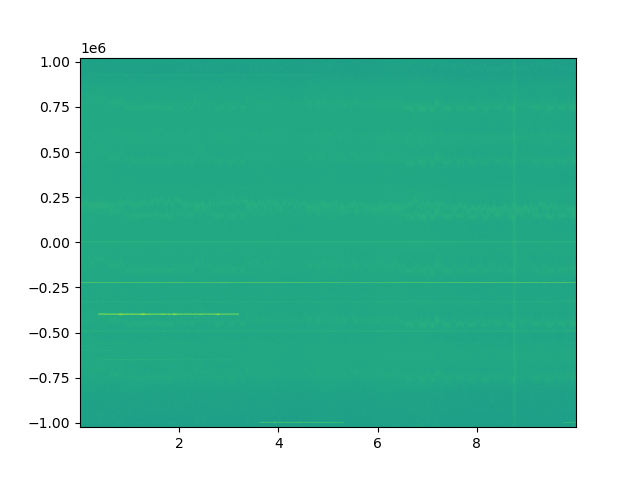

In [5]:
import matplotlib.pyplot as plt
%matplotlib widget
sp = plt.specgram(x=data, Fs=2048000, NFFT=2048)

Another good utility to see frequency content is to use **Power Spectral Density (PSD)** graph. 

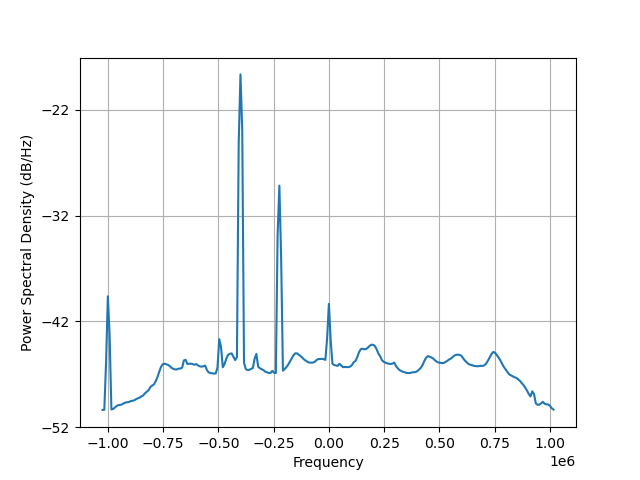

In [6]:
plt.figure()
psd = plt.psd(x=data, Fs=2048000)

## Time to demodulate
You should observe that there is a strong signal at -400kHz. So we must first shift signal by this offset to the right so that it appears at the center ie, 0Hz, then observe the resulting baseband signal.

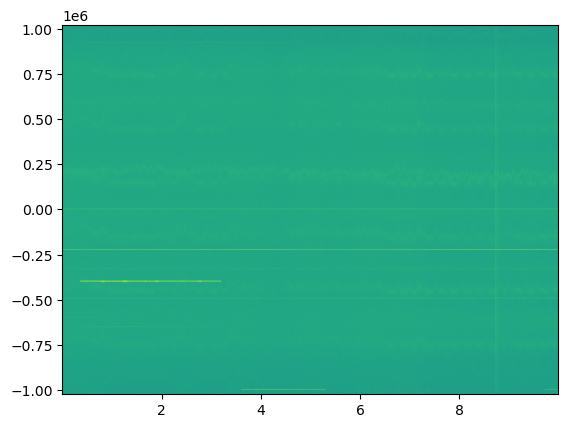

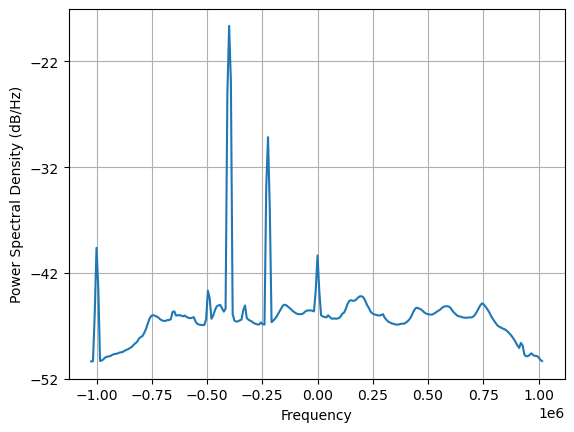

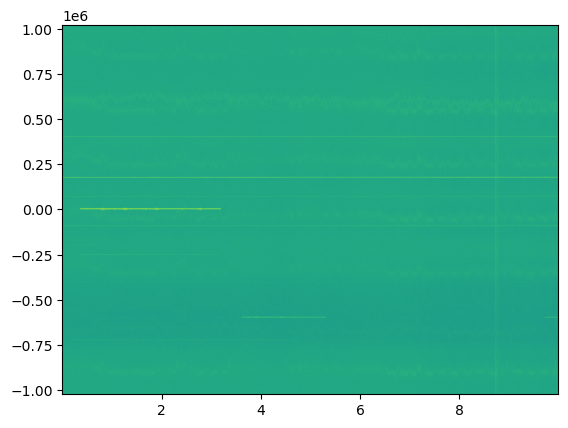

In [7]:
%matplotlib inline
import numpy as np
Fs = 2048000;
dt = 1 / Fs;
t = np.r_[:10:dt]
data_center = data * np.exp(1j*2*np.pi*(400000)*t);
plt.figure()
sp = plt.specgram(x=data_center, Fs=2048000, NFFT=2048)

Then AM demodulate it. Remember that you need to **decimate** the signal before sending it to sound card. Select a decimation value that suits your sound card. 

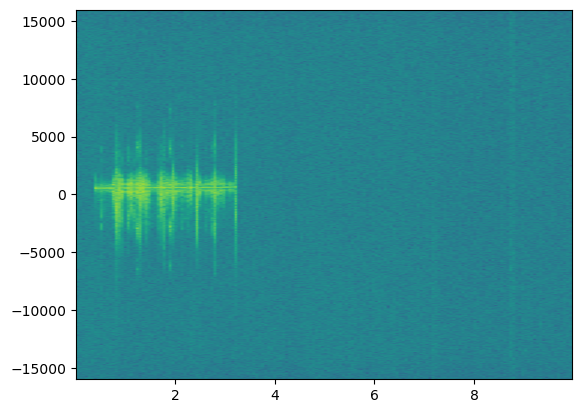

In [8]:
# Then decimate it by an amount to play it with our sound card. 
from scipy import signal
data_dec = signal.decimate(data_center, 64, ftype='fir')
sp = plt.specgram(x=data_dec, Fs=32000, NFFT=2048)

Now, we can play demodulated signal with our sound card. 

To install sounddevice use `conda install -c conda-forge python-sounddevice`

In [9]:
# normalize data before sending
import sounddevice as sd
data_demod = np.abs(data_dec)
max_val=np.max(data_demod)
data_demod = data_demod / max_val
sd.play(data_demod, 32000)
status = sd.wait()  # Wait until file is done playing

Write file in wav format. 

In [10]:
# create a wav file 
#audiowrite('rtl_am.wav', abs(data_demod/max(data_demod)), 32000)
from scipy.io.wavfile import write
write('rtl_am.wav', 32000, data_demod.astype(np.float32))  # Save as WAV file 

To install playsound use `pip install playsound==1.2.2`

In [11]:
from playsound import playsound
playsound('rtl_am.wav', 1)

ModuleNotFoundError: No module named 'playsound'

In [12]:
# in case you have trouble playing audio with 32k, resample for 48k
#data_sound = resample(abs(data_demod/max(data_demod)), 3, 2)
#sound(data_sound, 48000)
from scipy import signal
import sounddevice as sd
data_demod = np.abs(data_dec)
max_val=np.max(data_demod)
data_demod = data_demod / max_val
data_demod = signal.resample(data_demod, 48000*10)
sd.play(data_demod, 48000)
status = sd.wait()  # Wait until file is done playing

# Task-1

## Q1: Write a complete AM decoder function for RTL-SDR record (10 pts)

Package up what we have done to demodulate AM signal into a complete Python function, named `am_decoder`. You would use it to AM demodulate a record like this
``` 
import sounddevice as sd
sd.play(am_decoder('rtl_am.dat', -400000), 48000)
```
So, it would take 2 parameters: first filename, second offset frequency and return demodulated data at 48kHz. You can utilize existing `RTLSDRLoadRecord` function. 

## A1: Define your function in the below cell. 

In [13]:
def am_decoder(file_name, offset_frequency):
    Fs=2048000
    number_of_samples = os.path.getsize(file_name) / 2
    
    import numpy as np
    from scipy import signal
    from scipy import signal
    import sounddevice as sd
    
    data = np.fromfile(file_name, np.uint8)
    # change it to complex data
    data_c = data[::2] + 1j * data[1::2]
    # remove offset
    data = data_c - (128 + 1j * 128)

    dt = 1 / Fs;
    t = np.r_[:10:dt]
    data_center = data * np.exp(1j*2*np.pi*(-offset_frequency)*t);

    data_dec = signal.decimate(data_center, 42, ftype='fir')

    data_demod = np.abs(data_dec)
    max_val=np.max(data_demod)
    data_demod = data_demod / max_val
    data_demod = signal.resample(data_demod, 48000*10)

    return data_demod

## Q2: Other two frequencies (10 pts)
rtl_am.dat example record contains two other frequencies with activity. Spot these frequencies and write them below cell. Write both relative and real RF frequencies. 

## A2: Two other frequencies are: 

Other frequencies are in -1 MHz and -230kHz from center . So they are 134.5 Mhz and 135.27

## Q3: Test your function (10 pts)
Use your `am_decoder` function to test it. Make sure you hear something! Remember that this band is airband. You should hear some pilot-ground control communicaiton. Create two wav files named `other1.wav` and `other2.wav` using your function.  

In [21]:
# test with the example frequency = -400000
import sounddevice as sd
data_sound = am_decoder('rtl_am.dat', -400000);
sd.play(data_sound, 48000)

## A3-1: Wav record for other frequency1: 

In [22]:
write('other1.wav', 48000, am_decoder('rtl_am.dat', -1000000).astype(np.float32))  # Save as WAV file 

## A3-2: Wav record for other frequency2: 

In [23]:
write('other2.wav', 48000, am_decoder('rtl_am.dat', -230000).astype(np.float32))  # Save as WAV file 

# Task-2

Consider another example record given in your repo, `usrp_am.dat`. This file has been recorded using **USRP** set to **710kHz at a rate 256000sps** samples per second. File again contains IQ data, but with a different type. This time each I and Q component is now in **single precision** format.  

## Q4: How many samples are there and how long is this record in seconds? (10 pts)

In [24]:
import os
file_name = 'usrp_am.dat'
number_of_samples = os.path.getsize(file_name) / 8
print("Record contains " + str(int(number_of_samples)) + " complex samples and this corresponds to " + str(number_of_samples / 256000) + " seconds data. ")

Record contains 2736640 complex samples and this corresponds to 10.69 seconds data. 


## Q5: Write a Python function to read IQ data from this record. (10 pts)

In [2]:
def USRPLoadRecord(file_name):
    import numpy as np
    data = np.fromfile(file_name, np.float32)
    # change it to complex data
    data_c = data[::2] + 1j * data[1::2]
    # remove offset
    return data_c

## Q6: Plot the spectrogram (10 pts)

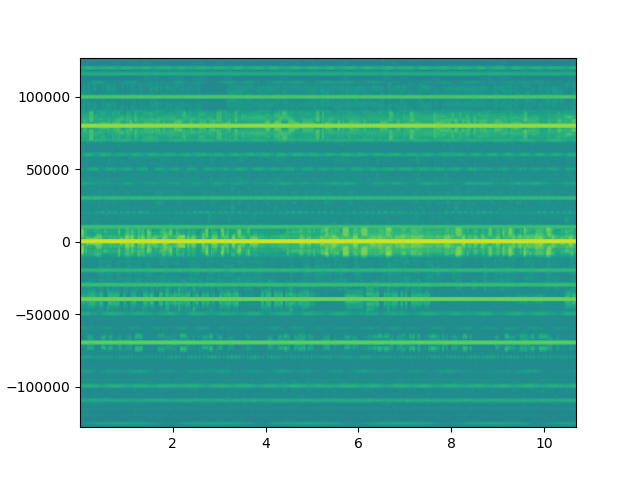

In [3]:
import matplotlib.pyplot as plt
data2=USRPLoadRecord('usrp_am.dat')
%matplotlib Widget
sp1 = plt.specgram(x=data2, Fs=256000)

## Q7: Demodulate baseband signal (10 pts)

In [29]:
    Fs=256000
    dt = 1 / Fs
    t = np.r_[:10.69:dt]
    data_center = data2 * np.exp(1j*2*np.pi*(0)*t);

    data_dec = signal.decimate(data_center, 5, ftype='fir')

    data_demod = np.abs(data_dec)
    max_val=np.max(data_demod)
    data_demod = data_demod / max_val
    sd.play(data_demod, 48000)

## Q8: Who do they talk about? (10 pts)

A8: They are talking about swimming and Mark Spitz gold medal at this sport

## Q9: List the most two other powerful signals in the record (10 pts)

A9: -68000 Hz and 80000 Hz from center are the most powerful signals we got. Therefore the signals are 642kHz and 790kHz

## Q10: Demodulate the second most powerful signal and save it as a wav file named usrp_am.wav (10 pts)

In [30]:
    Fs=256000
    dt = 1 / Fs
    t = np.r_[:10.69:dt]
    data_center = data2 * np.exp(1j*2*np.pi*(80000)*t);

    data_dec = signal.decimate(data_center, 5, ftype='fir')

    data_demod = np.abs(data_dec)
    max_val=np.max(data_demod)
    data_demod = data_demod / max_val
    write('usrp_am.wav', 48000, data_demod.astype(np.float32))

# Task-3 
## Q1: Capture the Signal - CTS (10pts)
Your instructor will be transmitting in airband, so tune to it and capture the signal! When you find it, first show it to your instructor, then put a screenshot below. 

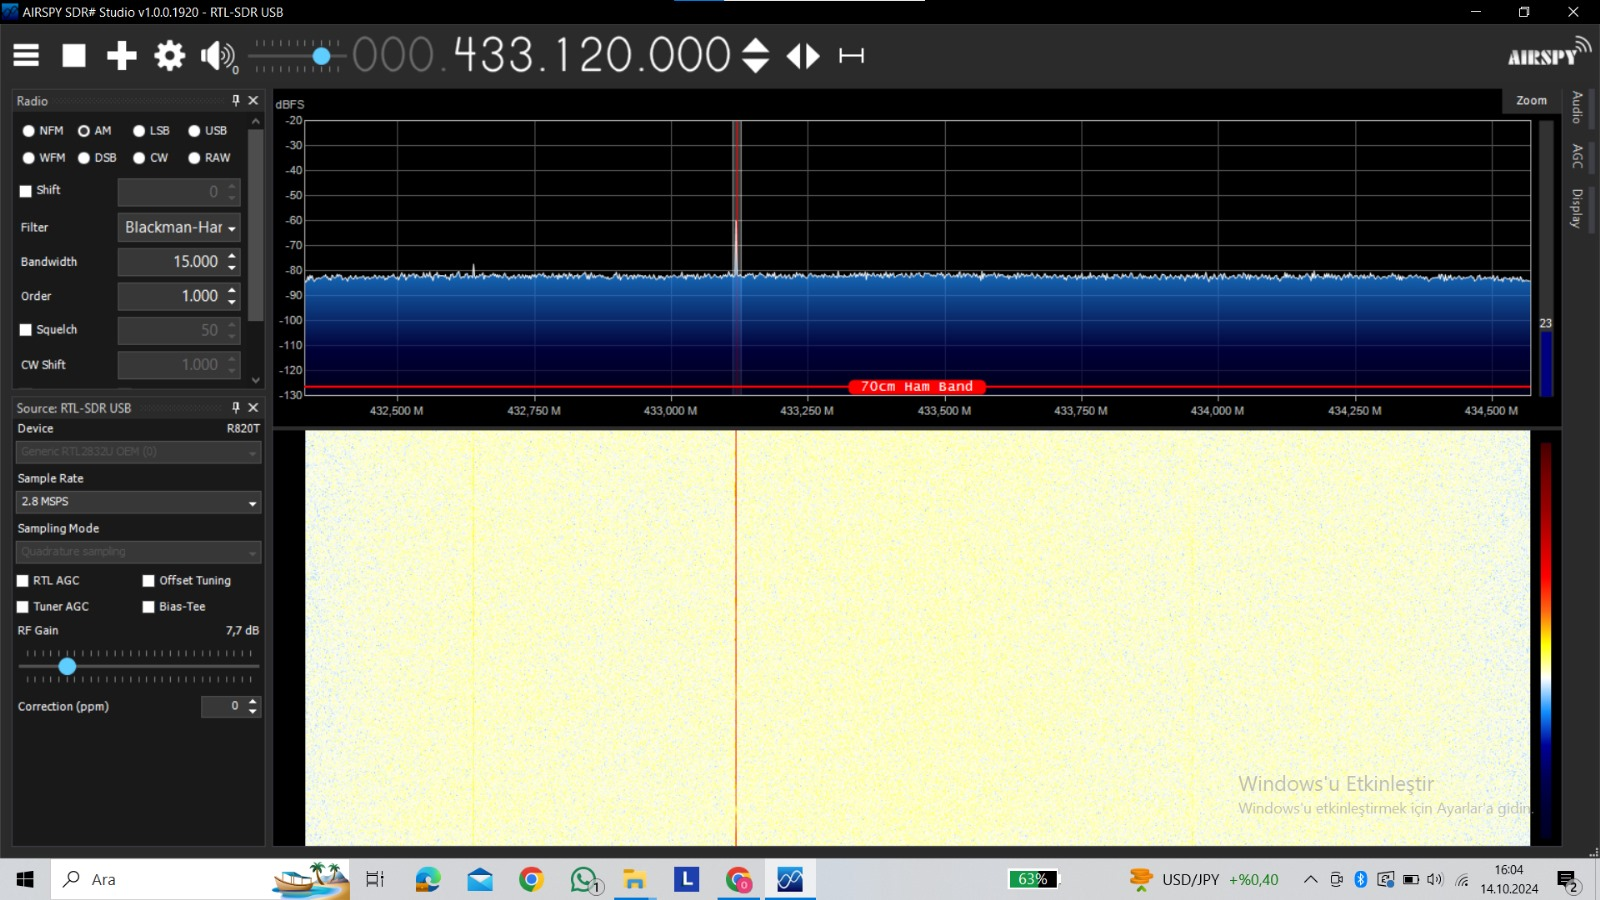

## Q2: Find the proper antenna length for the signal (10pts)
Hint: You may find [this page](https://www.rtl-sdr.com/using-our-new-dipole-antenna-kit/) helpful.  

Small Antenna, 4 Sections, 14cm + 2cm is resonant

## Q3: Write the flag (what you hear after you demodulate the signal) below (10pts)

A man counting the numbers and saying IRR(ay ar ar) something like that

## Q4: Take a 10-second record and demodulate it (30pts)
Take a 10-second record using `rtl_sdr`. Save it as `CTS.dat` and use this record to demodulate it. Save the sound file as `CTS.wav`. Your repo should contain all files.  

In [31]:
# rtl_sdr -f 433.120e6 -s 2.048e6 -g 28 -n 20480000 CTS2.dat


In [98]:
data_sound = am_decoder('CTS1.dat',0)
filtered_data = signal.lfilter(*signal.butter(15, 1500, fs=48000, btype='low'), data_sound)
write('CTS.wav', 48000, filtered_data.astype(np.float32))  # Save as WAV file 
